# Clase 27/05

Vamos a agarrar el los archivos sin ruido:
- ecg_sin_ruido.npy
- ppg_sin_ruido.npy
- la cucaracha.wav

Blackman-tukey (verlo en el libro de Hayes) => El valor medio TIENE que ser CERO


ESTANDARIZACION:
Z = {x - mean(x)} / std(x)

es como que "normaliza" x, y arma una variable Z nueva, pero normalizada


Los modelos parametricos, usan datos del modelo de la señal para estimar todavia MEJOR la señal. 
Osea, yo pudeo poner algo tipo "mi modelo de señal son 2 senoidales sumadas".


ecg => BW = 30 y tanto de Hz

ppg => BW = 10 Hz aprox


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal.windows import flattop, blackmanharris, hann
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io.wavfile import write

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

# Utilities de tareas anteriores

In [2]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        """
        Resuelve fs y n en caso de no ser provistos
        (se trata de igualar fs y n, en caso de no haber valores de ambos -< se lleva a nyquist)
        """

        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)

        elif fs is None:
            fs = n

        elif n is None:
            n = int(fs)

        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))

        return tt, xx

    @staticmethod
    def generar_sawtooth(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        # Fase expresada en ciclos
        fase_ciclos = ff * tt + ph / (2 * np.pi)

        rampa_01 = fase_ciclos - np.floor(fase_ciclos)

        # Escalar a -1 1
        xx = dc + vmax * (2 * rampa_01 - 1)

        return tt, xx

# Analisis de señales de señales

## Welch

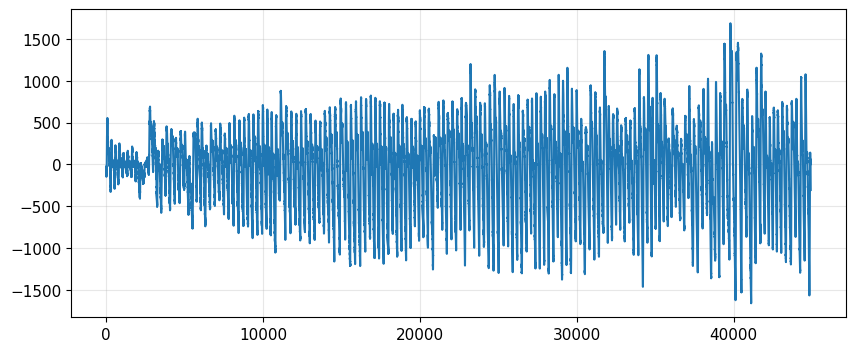

In [3]:
fs_ppg = 400 # Hz

ppg = np.load('ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)


In [11]:
def grafico_welch(ppg, fs = 1, k=2, pot_acum = 99, ax=None, xlim=None):
    N = len(ppg)
    nperseg = N // k 
    freqs, ppg_spec = sig.welch(ppg, fs=fs, nperseg=nperseg)
    
    ppg_spec_db = 10 * np.log10(ppg_spec + 1e-30)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    if xlim is not None:          # solo si me lo pasan
        ax.set_xlim(xlim)
    cota_inf, cota_sup = estimar_BW(freqs, ppg_spec, ax, pot_acum = pot_acum)

    ax.axvline(x=cota_inf, color='r', ls='--')
    ax.axvline(x=cota_sup, color='r', ls='--')
    ax.plot(freqs, ppg_spec, label=f"K = {k}", lw=1.5, alpha=0.8)

    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("PSD [dB]")
    ax.set_title(f"Welch — K = {k}, nperseg = {nperseg}")
    ax.grid(True, alpha=0.3)
    return ax

def estimar_BW(freqs, spec, ax, pot_acum):
    pot_inf = (100 - pot_acum)/2
    pot_sup = pot_acum + pot_inf
    
    pot = spec.cumsum()
    maximo = pot.max()
    pot =100 * pot/maximo
    
    cot_inf = np.argwhere(pot>pot_inf)[0][0]
    cot_sup = np.argwhere(pot>pot_sup)[0][0]
    cot_inf = freqs[cot_inf]
    cot_sup = freqs[cot_sup]
    
    print(f"la cota sup es {cot_sup}")
    print(f"la cota inf es {cot_inf}")
    
    #plt.plot(freqs,pot)
    return cot_inf, cot_sup
    

### PPG

la cota sup es 6.813627254509017
la cota inf es 0.1336005344021376


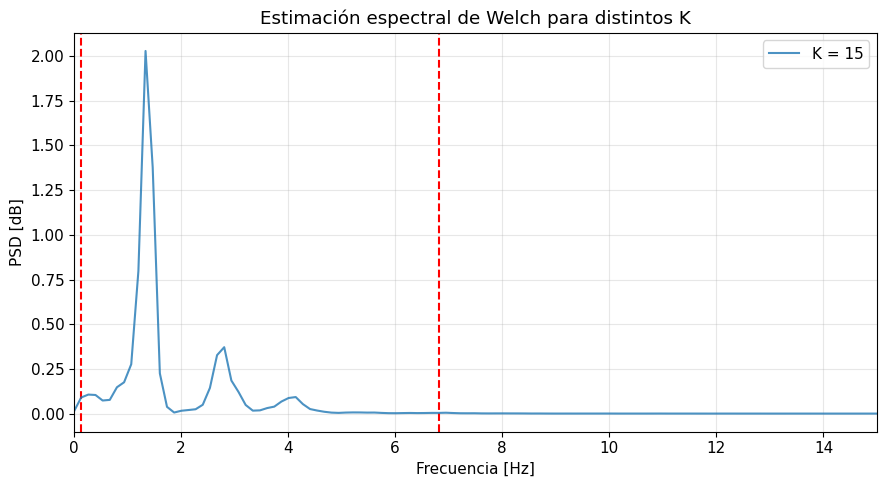

In [12]:
K_arr = [15]

ppg_2 = (ppg - np.mean(ppg)) / np.std(ppg)
fig, ax = plt.subplots(figsize=(9, 5))
for k in K_arr:
    grafico_welch(ppg_2,fs = fs_ppg, k=k, ax=ax, xlim=(0, 15))

ax.set_title("Estimación espectral de Welch para distintos K")
ax.legend()
plt.tight_layout()
plt.show()

### Silbido

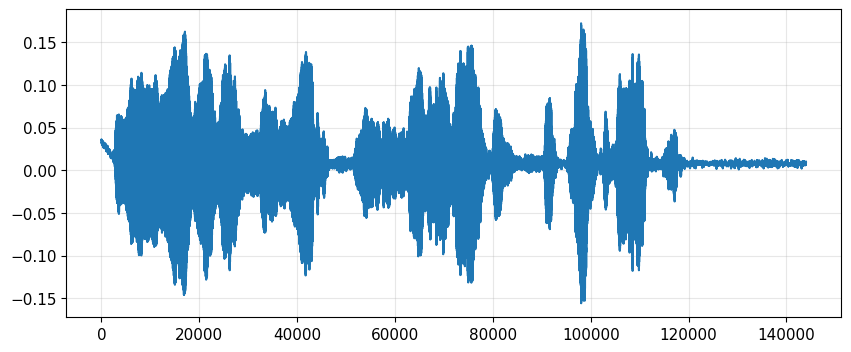

In [6]:
fs_audio_silbido, wav_data_silbido = sio.wavfile.read('silbido.wav')
# fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('silbido.wav')

plt.figure()
plt.plot(wav_data_silbido)

la cota sup es 6695.0
la cota inf es 2625.0


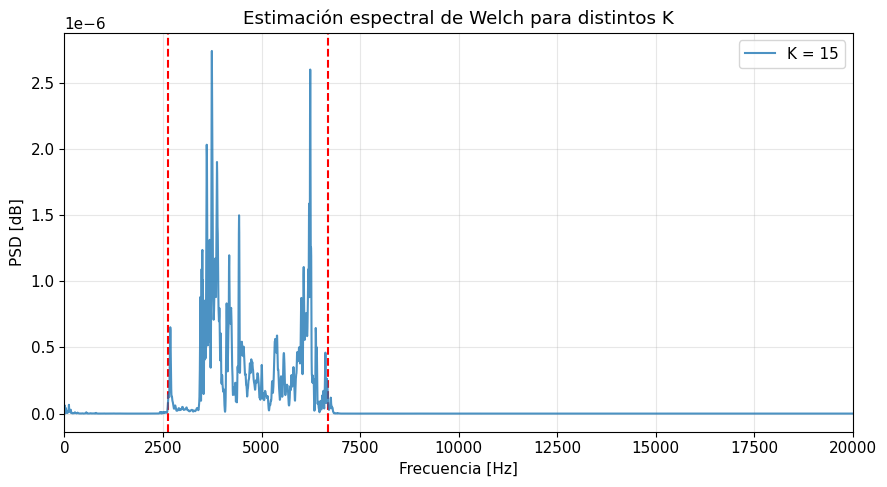

In [13]:
K_arr = [15]

fig, ax = plt.subplots(figsize=(9, 5))
for k in K_arr:
    grafico_welch(wav_data_silbido, fs = fs_audio_silbido, k=k, ax=ax, xlim=(0, 20e3))

ax.set_title("Estimación espectral de Welch para distintos K")
ax.legend()
plt.tight_layout()
plt.show()

### La cucarachaca

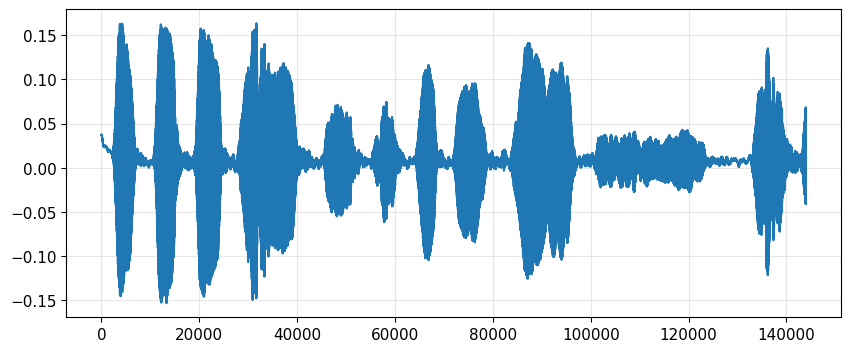

In [8]:
fs_audio_cucaracha, wav_data_cucaracha = sio.wavfile.read('la cucaracha.wav')
# fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('silbido.wav')

plt.figure()
plt.plot(wav_data_cucaracha)

la cota sup es 1970.0
la cota inf es 1010.0


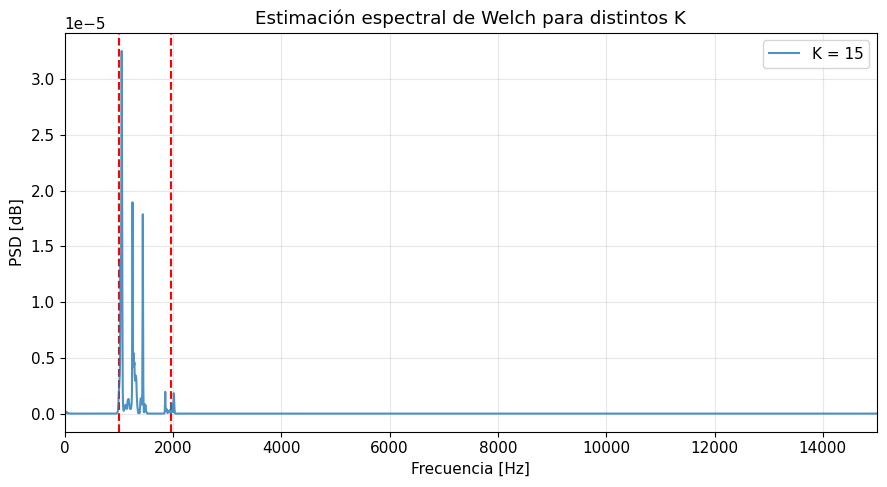

In [9]:
K_arr = [15]#1, 2, 10, 20, 100]

fig, ax = plt.subplots(figsize=(9, 5))
for k in K_arr:
    grafico_welch(wav_data_cucaracha, fs = fs_audio_cucaracha, k=k, ax=ax, xlim=(0, 15e3))

ax.set_title("Estimación espectral de Welch para distintos K")
ax.legend()
plt.tight_layout()
plt.show()

### Seno

/tmp/ipykernel_19678/4147660070.py:4: UserWarning: nperseg=45000 is greater than signal length max(len(x), len(y)) = 1, using nperseg = 1
  freqs, ppg_spec = sig.welch(ppg, fs=fs, nperseg=nperseg)
/tmp/ipykernel_19678/4147660070.py:30: RuntimeWarning: invalid value encountered in divide
  pot =100 * pot/maximo


IndexError: index 0 is out of bounds for axis 0 with size 0

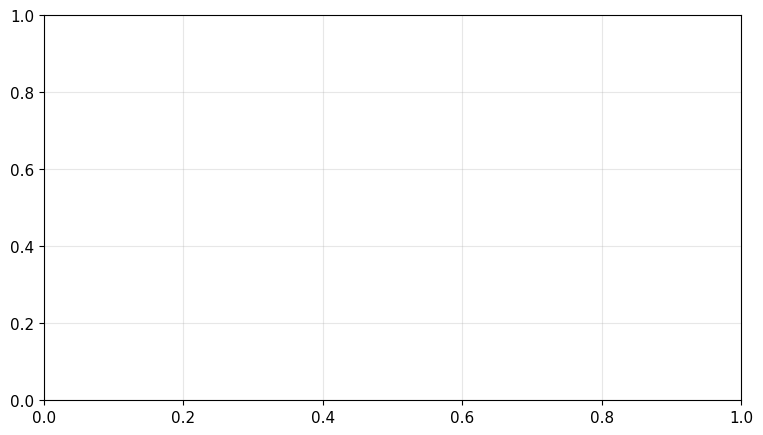

In [10]:

N = 45000
fs = 45000
f0 = 50
A = np.sqrt(2) # Potencia unitaria
tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)

K_arr = [1, 2, 10, 20, 100]

fig, ax = plt.subplots(figsize=(9, 5))
for k in K_arr:
    grafico_welch(xx, fs=fs, k=k, ax=ax)

ax.set_title("Estimación espectral de Welch para distintos K")
ax.legend()
plt.tight_layout()
plt.show()

# Blackman - Tukey

In [ ]:
def blackman_tukey(x,  M = None):    
    
    # N = len(x)
    x_z = x.shape
    
    N = np.max(x_z)
    
    if M is None:
        M = N//5
    
    r_len = 2*M-1

    # hay que aplanar los arrays por np.correlate.
    # usaremos el modo same que simplifica el tratamiento
    # de la autocorr
    xx = x.ravel()[:r_len];

    r = np.correlate(xx, xx, mode='same') / r_len

    Px = np.abs(np.fft.fft(r * sig.windows.blackman(r_len), n = N) )

    Px = Px.reshape(x_z)
    Px_db = 10*np.log10(Px)
    return Px;

In [ ]:
fs_ppg = 400 # Hz

ppg = np.load('ppg_sin_ruido.npy')

N = len(ppg)

plt.figure()
plt.plot(ppg)


In [ ]:
ft_XX_bt = blackman_tukey( xx, N//15 )


plt.plot(ft_XX_bt)
plt.xlim(0,100)